<font size="+3"><strong>Predicting Price with Neighborhood</strong></font>

In [18]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from category_encoders import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.utils.validation import check_is_fitted

In [19]:
# !pip install category-encoders

In the last lesson, we created a model that used location — represented by latitude and longitude — to predict price. In this lesson, we're going to use a different representation for location: neighborhood. 

## Prepare Data

### Import

In [40]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]

    # Split "lat-lon" column
    df[["lat", "lon"]] = df["lat-lon"].str.split(",", expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    # Extract Neighborhood
    df["neighborhood"] = df["place_with_parent_names"].str.split("|", expand = True)[3]
    df.drop(columns="place_with_parent_names", inplace=True)

    return df

In the last lesson, we used our `wrangle` function to import two CSV files as DataFrames. But what if we had hundreds of CSV files to import? Wrangling them one-by-one wouldn't be an option. So let's start with a technique for reading several CSV files into a single DataFrame. 

The first step is to gather the names of all the files we want to import. We can do this using pattern matching. <span style='color: transparent; font-size:1%'>WQU WorldQuant University Applied Data Science Lab QQQQ</span>

**Task 1:** Use [`glob`](https://docs.python.org/3/library/glob.html#glob.glob) to create a list that contains the filenames for all the Buenos Aires real estate CSV files in the `data` directory. Assign this list to the variable name `files`.

In [41]:
files = glob("buenos-aires-real-estate-*.csv")
files

['buenos-aires-real-estate-1.csv',
 'buenos-aires-real-estate-2.csv',
 'buenos-aires-real-estate-3.csv',
 'buenos-aires-real-estate-4.csv',
 'buenos-aires-real-estate-5.csv']

The next step is to read each of the CSVs in `files` into a DataFrame, and put all of those DataFrames into a list. A good way to iterate through `files` so we can achieve this is the use of `for` loop!

**Task 2:** Use your `wrangle` function in a `for` loop to create a list named `frames`. The list should the cleaned DataFrames created from the CSV filenames your collected in `files`.

In [42]:
frames = []
for file in files:
    df = wrangle(file)
    frames.append(df)

In [43]:
len(frames)

5

In [44]:
frames[1].head()

,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighborhood
2,sell,apartment,215000.0,USD,3259916.00,215000.00,40.0,35.0,5375.000000,6142.857143,NaN,1.0,3500.0,http://recoleta.properati.com.ar/12j4v_venta_d...,-34.588993,-58.400133,Recoleta
9,sell,apartment,341550.0,USD,5178717.72,341550.00,NaN,90.0,NaN,3795.000000,8.0,2.0,NaN,http://recoleta.properati.com.ar/100t0_venta_d...,-34.588044,-58.398066,Recoleta
12,sell,apartment,1386000.0,ARS,1382153.13,91156.62,39.0,33.0,2337.349231,42000.000000,NaN,NaN,NaN,http://monserrat.properati.com.ar/t05l_venta_d...,-34.623320,-58.397461,Monserrat
13,sell,apartment,105000.0,USD,1592052.00,105000.00,NaN,33.0,NaN,3181.818182,1.0,1.0,NaN,http://belgrano.properati.com.ar/zsd5_venta_de...,-34.553897,-58.451939,Belgrano
17,sell,apartment,89681.0,USD,1359779.19,89681.00,46.0,39.0,1949.586957,2299.512821,NaN,1.0,1500.0,http://villa-del-parque.properati.com.ar/12q2f...,-34.628813,-58.472230,Villa del Parque


The final step is to use pandas to combine all the DataFrames in `frames`. 

**Task 3:** Use [`pd.concat`](https://pandas.pydata.org/docs/reference/api/pandas.concat.html) to concatenate the items in `frames` into a single DataFrame `df`. Make sure you set the `ignore_index` argument to `True`.

In [45]:
df = pd.concat(frames, ignore_index = True)
print(df.shape)
df.head()

(6582, 17)


,operation,property_type,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon,neighborhood
0,sell,apartment,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693,Chacarita
1,sell,apartment,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115,Villa Luro
2,sell,apartment,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,-34.615847,-58.459957,Caballito
3,sell,apartment,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364.0,http://constitucion.properati.com.ar/k2f0_vent...,-34.625222,-58.382382,Constitución
4,sell,apartment,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450.0,http://once.properati.com.ar/suwa_venta_depart...,-34.610610,-58.412511,Once


### Explore

Looking through the output from the `df.head()` call above, there's a little bit more cleaning we need to do before we can work with the neighborhood information in this dataset. The good news is that, because we're using a `wrangle` function, we only need to change the function to re-clean all of our CSV files. This is why functions are so useful.

**Task 4:** Modify your `wrangle` function to create a new feature `"neighborhood"`. You can find the neighborhood for each property in the `"place_with_parent_names"` column. For example, a property with the place name `"|Argentina|Capital Federal|Palermo|"` is located in the neighborhood is `"Palermo"`. Also, your function should drop the `"place_with_parent_names"` column.

Be sure to rerun all the cells above before you continue.

In [46]:
#df["place_with_parent_names"].str.split("|", expand = True)[3]

### Split

At this point we can extract X_train and y_train from our dataset

**Task 5:** Create your feature matrix `X_train` and target vector `y_train`. `X_train` should contain one feature: `"neighborhood"`. Your target is `"price_aprox_usd"`. 

In [47]:
target = "price_aprox_usd"
features = ["neighborhood"]
y_train = df[target]
X_train = df[features]

## Build Model

### Baseline

**Task 6:** Calculate the baseline mean absolute error for your model.

In [48]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean]*len(y_train)

print("Mean apartment price:", y_mean)

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apartment price: 132383.83701458524
Baseline MAE: 44860.10834274133


### Iterate

If you try to fit a `LinearRegression` predictor to your training data at this point, you'll get an error that looks like this:

```
ValueError: could not convert string to float
```

What does this mean? When you fit a linear regression model, you're asking scikit-learn to perform a mathematical operation. The problem is that our training set contains neighborhood information in non-numerical form. In order to create our model we need to **encode** that information so that it's represented numerically. The good news is that there are lots of transformers that can do this. Here, we'll use the one from the [Category Encoders](https://contrib.scikit-learn.org/category_encoders/index.html) library, called a [`OneHotEncoder`](https://contrib.scikit-learn.org/category_encoders/onehot.html).

**Task 7:** First, instantiate a `OneHotEncoder` named `ohe`. Make sure to set the `use_cat_names` argument to `True`. Next, fit your transformer to the feature matrix `X_train`. Finally, use your encoder to transform the feature matrix `X_train`, and assign the transformed data to the variable `XT_train`.

In [53]:
ohe = OneHotEncoder(use_cat_names=True)
# Fit
#ohe.fit(X_train)
XT_train = ohe.fit_transform(X_train)
print(XT_train.shape)
XT_train.head()

(6582, 57)


,neighborhood_Chacarita,neighborhood_Villa Luro,neighborhood_Caballito,neighborhood_Constitución,neighborhood_Once,neighborhood_Almagro,neighborhood_Palermo,neighborhood_Flores,neighborhood_Belgrano,neighborhood_Liniers,...,neighborhood_Puerto Madero,neighborhood_Agronomía,neighborhood_Monte Castro,neighborhood_Tribunales,neighborhood_Villa Santa Rita,neighborhood_Velez Sarsfield,neighborhood_Villa Soldati,neighborhood_Villa Real,neighborhood_Pompeya,neighborhood_Catalinas
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
# XT_train.head(30)

**Task 8:** Create a pipeline named `model` that contains a `OneHotEncoder` transformer and a `LinearRegression` predictor. Then fit your model to the training data. 

In [55]:
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    # LinearRegression(),
    Ridge()
)

model.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighborhood'], use_cat_names=True)),
                ('ridge', Ridge())])

### Evaluate

Regardless of how you build your model, the evaluation step stays the same. Let's see how our model performs with the training set.

**Task 9:** First, create a list of predictions for the observations in your feature matrix `X_train`. Name this list `y_pred_training`. Then calculate the training mean absolute error for your predictions in `y_pred_training` as compared to the true targets in `y_train`.

In [56]:
y_pred_training = model.predict(X_train)
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 39350.22


## Communicate Results

If we write out the equation for our model, it'll be too big to fit on the screen. That's because, when we used the `OneHotEncoder` to encode the neighborhood data, we created a much wider DataFrame, and each column/feature has it's own coefficient in our model's equation.

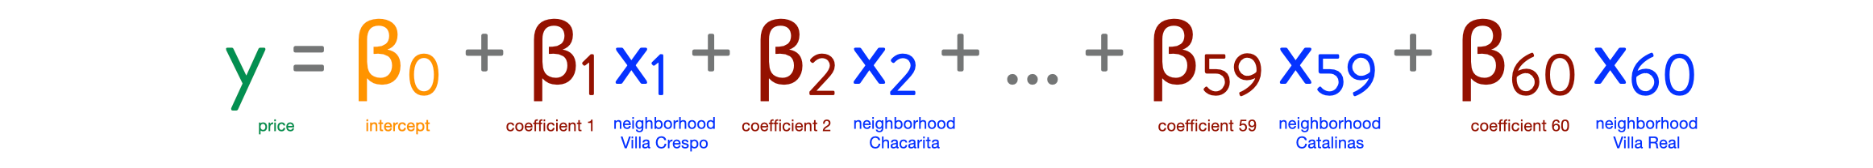

This is important to keep in mind for two reasons. First, it means that this is a **high-dimensional** model. Instead of a 2D or 3D plot, we'd need a 58-dimensional plot to represent it, which is impossible! Second, it means that we'll need to extract and represent the information for our equation a little differently than before. Let's start by getting our intercept and coefficient.

**Task 10:** Extract the intercept and coefficients for your model. 

In [57]:
intercept = model.named_steps["ridge"].intercept_
coefficients = model.named_steps["ridge"].coef_
print("coefficients len:", len(coefficients))
print(coefficients[:5])  # First five coefficients

coefficients len: 57
[-2.89895934e+03 -6.29555347e+00  9.25289088e+03 -4.17487330e+04
 -3.23037446e+03]


We have the values of our coefficients, but how do we know which features they belong to? We'll need to get that information by going into the part of our pipeline that did the encoding.

**Task 11:** Extract the feature names of your encoded data from the `OneHotEncoder` in your model.

In [58]:
feature_names = model.named_steps["onehotencoder"].get_feature_names_out()
print("features len:", len(feature_names))
print(feature_names[:5])  # First five feature names

features len: 57
['neighborhood_Chacarita' 'neighborhood_Villa Luro'
 'neighborhood_Caballito' 'neighborhood_Constitución' 'neighborhood_Once']
